# Figure 6.6-1 &mdash; The pressure-volume behavior of the van der Waals EOS

This notebook reproduces **Figure 6.6-1**: isotherms of the van der Waals equation of
state in the reduced pressure-volume plane, above and below the critical isotherm.

It is written on the **reduced** form of the equation, so the curves are the same for
every fluid &mdash; the result Sec. 6.6 establishes, and the reason the figure carries no
substance name.

The companion notebook `ch7/van_der_waals_EOS.ipynb` continues with the same equation of
state into Figures 7.3-1 through 7.3-4: the local maxima and minima of a sub-critical
isotherm, the fugacity construction, and the vapor-liquid coexistence region.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

<small>Copyright (c) 2025 Eric M. Furst</small>


In [ ]:
# --- Colab bootstrap -------------------------------------------------------
# The axis labels below use the book's molar underbar, \underline{V}. With no LaTeX
# installed, matplotlib renders math with its own mathtext engine, which only learned
# \underline in 3.11 -- and Colab still ships 3.10. This upgrades it there, and does
# nothing at all on a machine that already has 3.11 or newer.
#
# ON COLAB THIS NEEDS A SESSION RESTART. Colab imports matplotlib as the session
# starts, so pip can replace the files on disk but not the module already loaded in
# memory: without a restart the kernel keeps running 3.10 and the labels still fail.
# One click, once per session. The cell prints the instruction when it applies.
import sys
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("\n" + "=" * 72)
        print("  matplotlib was upgraded so this notebook can draw the book's notation.")
        print("  RESTART NOW:   Runtime > Restart session,   then Run all.")
        print("  Colab only, once per session. Without it the next figure will fail.")
        print("=" * 72 + "\n")
# ---------------------------------------------------------------------------

## van der Waals equation of state

Below are routines to calculate the van der Waals equation of state.

The van der Waals equation of state (vdW EOS) is

$$ P = \frac{RT}{\underline{V}-b} - \frac{a}{\underline{V}^2} \tag{Eq. 6.2-38b}$$

Like other cubic equations of state, calculating the pressure $P$ given $\underline{V}$ and $T$ is straightforward, but to calculate the molar volume given $P$ and $T$, we need to solve a cubic equation of the form

$$ Z^3 + \alpha Z^2 + \beta Z + \gamma = 0 \tag{Eq. 6.4-4}$$

where $Z$ is the compressibility factor

$$ Z = \frac{P \underline{V{}}}{RT} $$

For the van der Waals EOS (see SIS **Table 6.4-3**),

$$ \alpha = -1 - B $$
$$ \beta = A $$
$$ \gamma = -AB $$

and 

$$ A = \frac{aP}{(RT)^2} $$
$$ B = \frac{bP}{RT} $$

Here, we will use the reduced van der Waals equation of state

$$ \left ( P_r + \frac{3}{\underline{V}_r} \right )(3\underline{V}_r - 1) = 8T_r \tag{Eq. 6.6-6}$$

This can be written in the form 

$$ \underline{V}_r^3 + \alpha \underline{V}_r^2 + \beta \underline{V}_r + \gamma = 0 $$

with

$$\alpha = -\frac{P_r+8T_r}{3P_r}$$
$$\beta = \frac{3}{P_r}$$
$$\gamma = -\frac{1}{P_r}$$

which is left as an exercise for the reader.

In [1]:
"""
Reduced van der Waals equation of state 
rvdw_P returns the pressure given Vr, Tr
rvdw_V returns all reduced molar volumes (real roots of EOS) given Pr and Tr
"""
import numpy as np
from numpy.polynomial import Polynomial


# Calculate the reduced presure given Vr, Tr for reduced vdw EOS
def rvdw_P(Vr,Tr):

    return 8*Tr/(3*Vr-1) - 3/Vr**2

# Calculate the reduced molar volume given Pr, Tr
# Note that we can return multiple real roots (up to three)
# The largest and smallest will be the vapor and liquid, respectively
def rvdw_V(Pr, Tr):

    # Definitions of alpha, beta, gamma in SIS Table 6.4-3 for PR EOS
    alpha = -(Pr+8*Tr)/3/Pr
    beta = 3/Pr
    gamma = -1/Pr

    # polynomial with coefficients in increasing order: c0 + c1 x + c2 x**2 + ...
    p = Polynomial([ gamma, beta, alpha, 1 ])  

    roots = p.roots()        # returns all (possibly complex) roots of Z
    real_roots = roots.real[abs(roots.imag) < 1e-12]  # filter real ones

    return real_roots



## Figure 6.6-1

We plot isotherms on the reduced scale, a few above and below the critical isotherm.


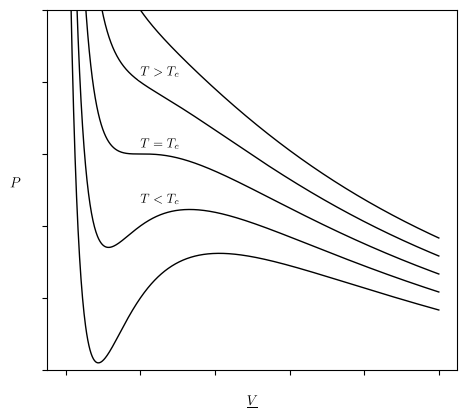

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.transforms import offset_copy

# Use a real LaTeX installation when there is one, and matplotlib's own
# mathtext otherwise — so this notebook also runs in Colab, which has no TeX.
from shutil import which
mpl.rcParams["text.usetex"] = which("latex") is not None

# Good PDF defaults
mpl.rcParams.update({
    "pdf.fonttype": 42,   # keep text as text in PDF
    "ps.fonttype": 42,
})

# Function to make plot labels
def label_curve(
    ax,
    x, y, text,
    *,
    dx=0, dy=3,          # offset in points
    ha="left", va="bottom",
    fontsize=9,
    bbox=True
):
    """
    Place a text label in data coordinates with a point offset.
    """
    transform = offset_copy(ax.transData, fig=ax.figure, x=dx, y=dy, units="points")

    bbox_kw = None
    if bbox:
        bbox_kw = dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2")

    ax.text(float(x), float(y), text, ha=ha, va=va, fontsize=fontsize, transform=transform,
        bbox=bbox_kw)

# Make the plot
fig, ax = plt.subplots(figsize=(5.0, 4.5))  # choose size you like

# Range of reduced molar volumes
Vr_max = 3
Vr_min = 0.5
Vr = np.linspace(Vr_min,Vr_max,1000)

# plot the labeled lines, 0.95, 1.0, 1.05
Tr = 0.95
ax.plot(Vr, rvdw_P(Vr,Tr), '-',label=Tr, color="black", linewidth=1)
label_curve(ax, 1, rvdw_P(1,Tr), rf"$T < T_c$", dy=15)

Tr = 1.0
ax.plot(Vr, rvdw_P(Vr,Tr), '-',label=Tr, color="black", linewidth=1)
label_curve(ax, 1, rvdw_P(1,Tr), rf"$T = T_c$")

Tr = 1.05
ax.plot(Vr, rvdw_P(Vr,Tr), '-',label=Tr, color="black", linewidth=1)
label_curve(ax, 1, rvdw_P(1,Tr), rf"$T > T_c$")

# plot several isotherms above the critical temperature
for Tr in np.array([0.9, 1.1]): 
    ax.plot(Vr, rvdw_P(Vr,Tr), '-',label=Tr, color="black", linewidth=1)

plt.ylim([0.4,1.4])
plt.xlabel(r"$\underline{V}$", labelpad=15)
plt.ylabel(r'$P$', rotation=0, labelpad=20)

fig.tight_layout()

ax.tick_params(
    labelbottom=False,
    labelleft=False
)

# ---- SAVE HIGH-QUALITY PDF ----
import os; os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_6.6-1.pdf", bbox_inches="tight", pad_inches=0.02)

plt.show()